In [1]:
import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import pandas as pd
from scipy import stats
import time
from tqdm import tqdm

import uproot
from torch.utils.data import DataLoader, Dataset

import sys
import os
# Manually point to the 'src' folder
sys.path.insert(0, "/home/xzcapnai/hepattn/hepattn/src")

from hepattn.experiments.mu3e.data import Mu3eDataModule

In [2]:
all_hits_batched_dir = "/home/xzcapnai/hepattn/hepattn/src/hepattn/experiments/mu3e/data/train/all_hits.parquet"
all_tracks_batched_dir = "/home/xzcapnai/hepattn/hepattn/src/hepattn/experiments/mu3e/data/train/all_tracks.parquet"

all_hits_dir = "/home/xzcapnai/hepattn/hepattn/src/hepattn/experiments/mu3e/data/train_batch_size_1/all_hits.parquet"
all_tracks_dir = "/home/xzcapnai/hepattn/hepattn/src/hepattn/experiments/mu3e/data/train_batch_size_1/all_tracks.parquet"

In [3]:
all_hits_batched = pd.read_parquet(all_hits_batched_dir, engine='fastparquet')
all_tracks_batched = pd.read_parquet(all_tracks_batched_dir, engine='fastparquet')

all_hits = pd.read_parquet(all_hits_dir, engine='fastparquet')
all_tracks = pd.read_parquet(all_tracks_dir, engine='fastparquet')

In [4]:
print(f"num_events in all_hits_batched : {len(all_hits_batched['eventID'].unique())}")
print(f"num_events in all_tracks_batched : {len(all_tracks_batched['eventID'].unique())}")

print(f"num_events in all_hits : {len(all_hits['eventID'].unique())}")
print(f"num_events in all_tracks : {len(all_tracks['eventID'].unique())}")

num_events in all_hits_batched : 18749
num_events in all_tracks_batched : 18749
num_events in all_hits : 37383
num_events in all_tracks : 37383


In [5]:
def load_event(sample_id, all_hits, all_tracks):
    hits = all_hits[all_hits['eventID'] == sample_id].copy()
    particles = all_tracks[all_tracks['eventID'] == sample_id].copy()
    
    # Scale spatial coordinates into 0-1 range
    for coord in ["x", "y", "z"]:
            hits[coord] *= 0.01

    for coord in ["px", "py", "pz"]:
        particles[coord] *= 0.01
        hits[coord] *= 0.01
    
    # Add extra hit fields
    hits["r"] = np.sqrt(hits["x"] ** 2 + hits["y"] ** 2)
    hits["s"] = np.sqrt(hits["x"] ** 2 + hits["y"] ** 2 + hits["z"] ** 2)
    hits["lambda"] = np.arccos(hits["z"] / hits["s"])
    hits["phi"] = np.arctan2(hits["y"], hits["x"])
    hits["eta"] = -np.log(np.tan(hits["lambda"] / 2))
    hits["u"] = hits["x"] / (hits["x"] ** 2 + hits["y"] ** 2)
    hits["v"] = hits["y"] / (hits["x"] ** 2 + hits["y"] ** 2)

    # Add extra particle fields
    particles["p"] = np.sqrt(particles["px"] ** 2 + particles["py"] ** 2 + particles["pz"] ** 2)
    particles["pt"] = np.sqrt(particles["px"] ** 2 + particles["py"] ** 2)
    particles["eta"] = np.arctanh(particles["pz"] / particles["p"])
    particles["lambda"] = np.arccos(particles["pz"] / particles["p"])
    particles["phi"] = np.arctan2(particles["py"], particles["px"])
    particles["coslambda"] = np.cos(particles["lambda"])
    particles["sinlambda"] = np.sin(particles["lambda"])
    particles["cosphi"] = np.cos(particles["phi"])
    particles["sinphi"] = np.sin(particles["phi"])

    # Apply particle cut based on hit content
    counts = hits["trackID"].value_counts()
    keep_particle_ids = counts[counts >= 4].index.to_numpy()
    particles = particles[particles["trackID"].isin(keep_particle_ids)]

    # Re-index tracks per event
    particles["particle_idx"] = np.arange(len(particles))
    trackID_to_idx = dict(zip(particles['trackID'].values, particles['particle_idx'].values))
    assert len(trackID_to_idx) == len(particles), "trackID to particle_idx mapping is not one-to-one"

    hits["particle_idx"] = hits["trackID"].map(trackID_to_idx)
    hits = hits.dropna(subset=['particle_idx'])
    hits['particle_idx'] = hits['particle_idx'].astype(int)
    assert hits["particle_idx"].min() >= 0, "particle_idx to hit mapping failed"
    assert hits["particle_idx"].max() < len(particles), "particle_idx to hit mapping failed"

    # Mark which hits are on a valid / reconstructable particle, for the hit filter
    hits["on_valid_particle"] = hits["particle_idx"].isin(particles["particle_idx"])

    # Sanity checks
    assert len(particles) != 0, "No particles remaining - loosen selection!"
    assert len(hits) != 0, "No hits remaining - loosen selection!"
    assert particles["trackID"].nunique() == len(particles), "Non-unique particle ids"

    return hits, particles

In [6]:
def fit_circle(x_hits, y_hits):
    A, B, C, D = (x_hits[0], y_hits[0]), (x_hits[1], y_hits[1]), (x_hits[2], y_hits[2]), (x_hits[3], y_hits[3])

    a, b = A
    c, d = B
    x0, y0 = C

    alpha = ((x0-a)*(x0-c) + (y0-b)*(y0-d)) / ((b-d)*x0 - (a-c)*y0 + a*d - b*c)

    xc = ((a+c) + alpha*(b-d)) / 2
    yc = ((b+d) - alpha*(a-c)) / 2
    r2 = alpha * (a*d - b*c) - a*c - b*d + xc**2 + yc**2
    r = np.sqrt(r2)

    th = np.arange(0, 2*np.pi, 0.01)
    x, y = r * np.cos(th) + xc, r * np.sin(th) + yc
    
    return x, y

def fit_circle_arc(x_hits, y_hits, vx, vy, npts=300):
    # ---- circle fit (same as before) ----
    A, B, C = (
        (x_hits[0], y_hits[0]),
        (x_hits[1], y_hits[1]),
        (x_hits[2], y_hits[2]),
    )

    a, b = A
    c, d = B
    x0, y0 = C

    alpha = ((x0-a)*(x0-c) + (y0-b)*(y0-d)) / (
        (b-d)*x0 - (a-c)*y0 + a*d - b*c
    )

    xc = ((a+c) + alpha*(b-d)) / 2
    yc = ((b+d) - alpha*(a-c)) / 2
    r = np.sqrt(alpha * (a*d - b*c) - a*c - b*d + xc**2 + yc**2)

    # ---- angles from vertex + hits ----
    x_all = np.concatenate([[vx], x_hits])
    y_all = np.concatenate([[vy], y_hits])

    theta = np.arctan2(y_all - yc, x_all - xc)

    # unwrap angles so they evolve continuously along the track
    theta = np.unwrap(theta)

    theta_arc = np.linspace(theta[0], theta[-1], npts)

    x_arc = xc + r * np.cos(theta_arc)
    y_arc = yc + r * np.sin(theta_arc)

    return x_arc, y_arc

In [7]:
def plot_event(
    hits,
    particles,
):
    plt.style.use('default') 

    num_particles = len(particles)
    eventID = hits['eventID'].values[0]
    
    pid_label = {11: "e-", -11: "e-"}

    fig, (ax1, ax2) = plt.subplots(
        1, 2, 
        figsize=(17, 6), 
        dpi=250, 
        sharey=True, 
        gridspec_kw={'width_ratios': [200, 460]}
    )
    
    plt.suptitle(f'Event {idx} | No. Particles = {num_particles}', fontsize=15)
    # -------------------------
    # Plot 1: XY Plane
    # -------------------------
    ax1.set_xlim(-100, 100)
    ax1.set_ylim(-100, 100)
    ax1.set_aspect('equal')

    ax1.plot(0, 0, 'x', color='black', alpha=0.5)

    for r in [23.3, 29.8, 73.9, 86.3]:
        ax1.add_patch(
            plt.Circle((0, 0), r, color='black', lw=0.3, fill=False)
        )
        
    ax1.add_patch(plt.Circle((0,0), 19, color='green', alpha=0.2, label='Target'))
    # -------------------------
    # Plot 2: ZY Plane
    # -------------------------
    ax2.set_xlim(-250, 210)
    ax2.set_ylim(-100, 100)
    ax2.set_aspect('equal')

    ax2.plot(0, 0, 'x', color='black', alpha=0.5)

    # finite detector layers in Z
    ax2.hlines(y=[+23.3, -23.3], xmin=-62.35,  xmax=62.35,  color='black', lw=0.3)
    ax2.hlines(y=[+29.8, -29.8], xmin=-62.35,  xmax=62.35,  color='black', lw=0.3)
    ax2.hlines(y=[+73.9, -73.9], xmin=-175.95, xmax=175.95, color='black', lw=0.3)
    ax2.hlines(y=[+86.3, -86.3], xmin=-186.3, xmax=186.3, color='black', lw=0.3)
    
    stopping_target_pts_1 = np.array([[-50, 0], [0, 19], [0, -19]])
    stopping_target_pts_2 = np.array([[50, 0], [0, 19], [0, -19]])
    triangle1 = plt.Polygon(stopping_target_pts_1, closed=True, color='green', alpha=0.2, label='Target')
    triangle2 = plt.Polygon(stopping_target_pts_2, closed=True, color='green', alpha=0.2)    
    
    ax2.add_patch(triangle1)
    ax2.add_patch(triangle2)

    # -------------------------
    # Tracks
    # -------------------------
    for i, particle_idx in enumerate(hits['particle_idx'].unique()):
        particle_hits = hits[hits['particle_idx'] == particle_idx].copy()
        individual_particle = particles[particles['particle_idx'] == particle_idx]
        pdg = int(individual_particle['pdg'])

        vx = individual_particle['vx'].values[0]
        vy = individual_particle['vy'].values[0]
        vz = individual_particle['vz'].values[0]

        x_hits = particle_hits['x'].values * 100 
        y_hits = particle_hits['y'].values * 100
        z_hits = particle_hits['z'].values * 100

        x_path = np.insert(x_hits, 0, vx)
        y_path = np.insert(y_hits, 0, vy)
        z_path = np.insert(z_hits, 0, vz)

        # XY circle fit
        circle_x, circle_y = fit_circle(x_hits, y_hits)

        #line, = ax1.plot(vx, vy, 'o')
        #color = line.get_color()

        line, = ax1.plot(x_path, y_path, '--', alpha=0.5) 
        color = line.get_color()
        ax1.plot(vx, vy, 'o', color=color)

        #ax1.plot(circle_x, circle_y, '--', alpha=0.5, color=color)
        ax1.plot(x_hits, y_hits, 'x', color=color,
                 label=f'pid={i} | {pid_label[pdg]}')

        # ZY projection
        ax2.plot(z_path, y_path, '--', alpha=0.5, color=color)
        ax2.plot(vz, vy, 'o', color=color)
        ax2.plot(z_hits, y_hits, 'x', color=color,
                 label=f'pid={i} | {pid_label[pdg]}')

    # -------------------------
    # Labels & legends
    # -------------------------
    ax1.set_xlabel('x-axis [mm]')
    ax1.set_ylabel('y-axis [mm]')
    ax2.set_xlabel('z-axis [mm]')

    ax1.grid(alpha=0.1)
    ax2.grid(alpha=0.1)
    ax2.legend(loc='center left')
    plt.tight_layout()
    
    return fig

/tmp/ipykernel_100231/1523789150.py:65: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  pdg = int(individual_particle['pdg'])


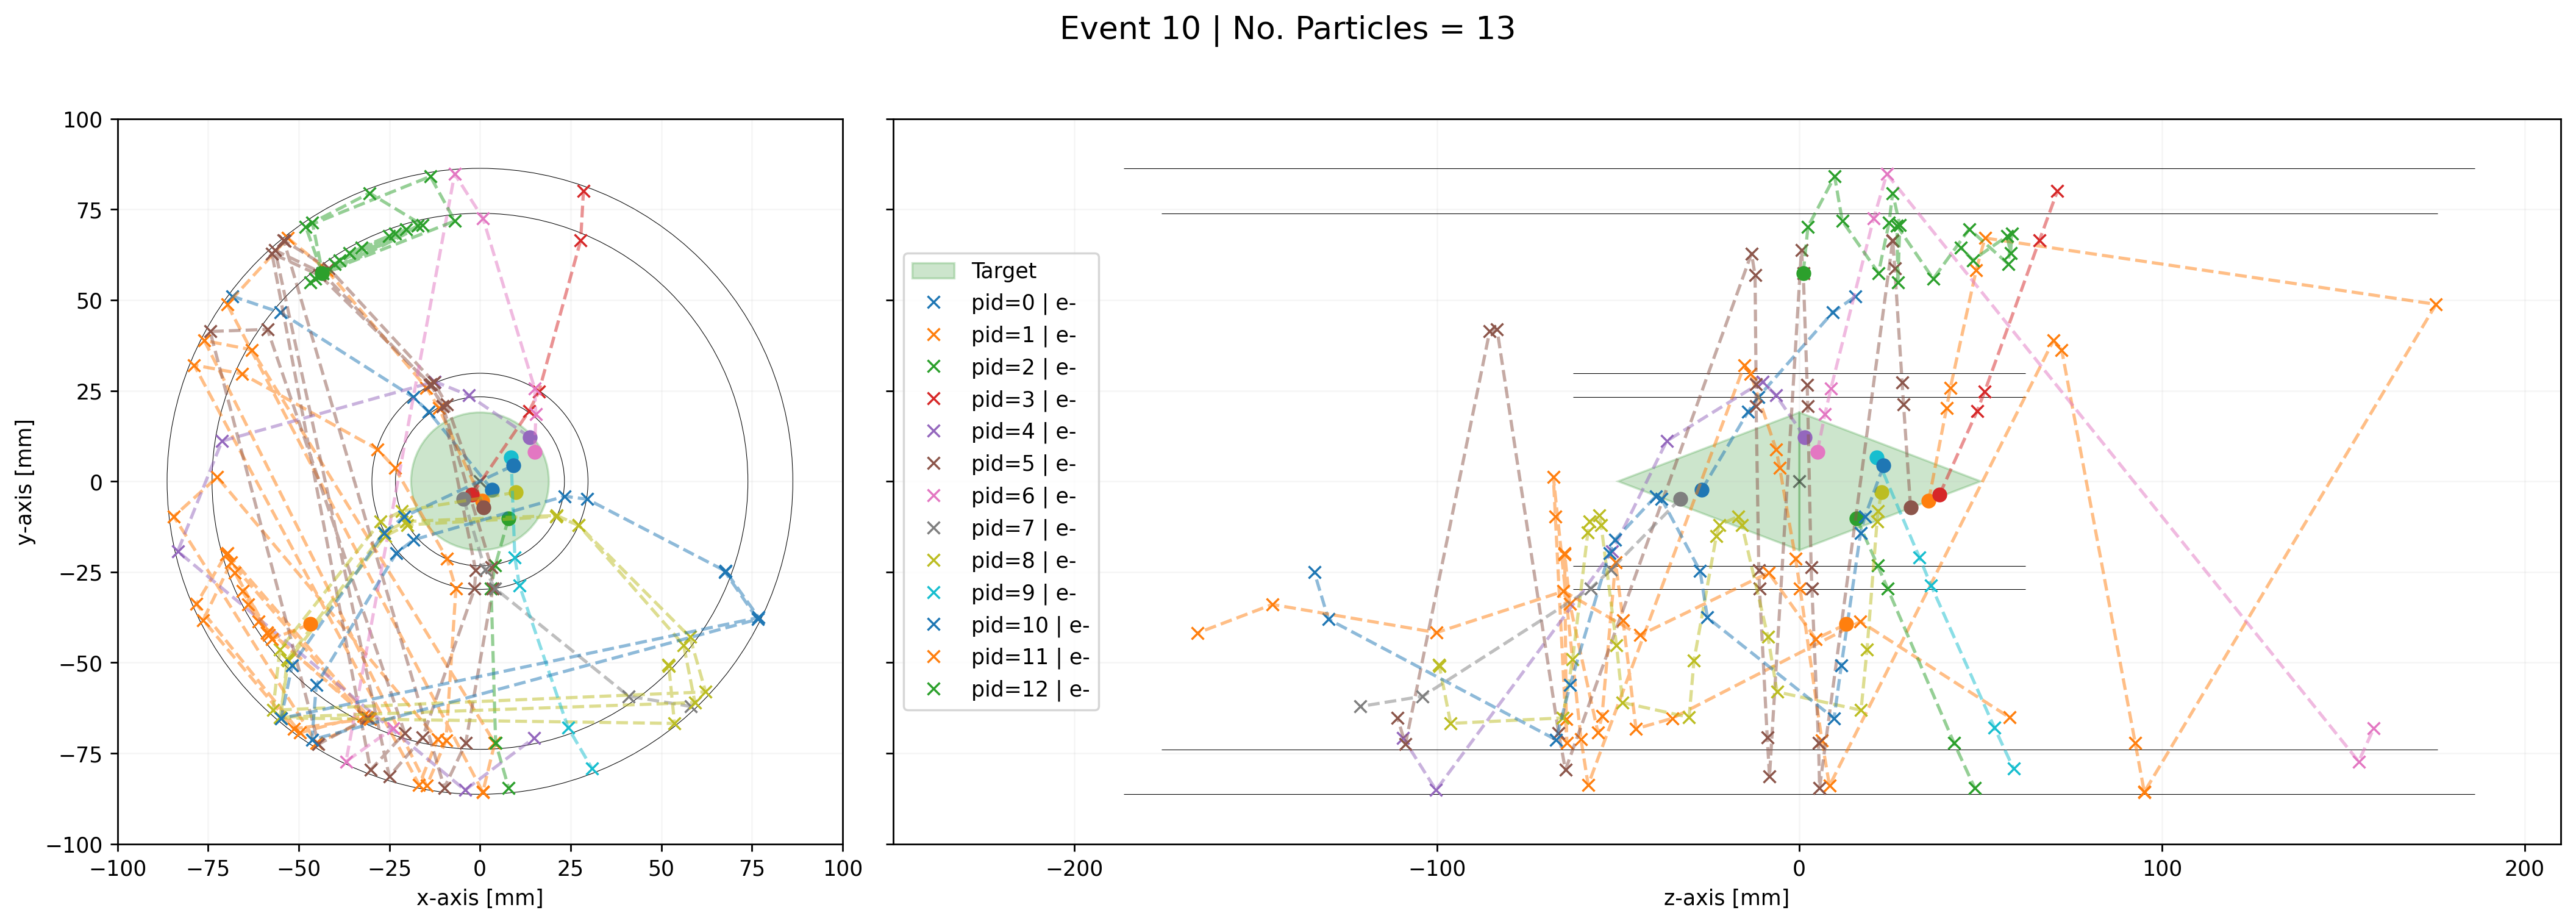

In [15]:
idx = 10
hits, particles = load_event(idx, all_hits_batched, all_tracks_batched)
fig = plot_event(hits, particles)

/tmp/ipykernel_213846/1523789150.py:65: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  pdg = int(individual_particle['pdg'])


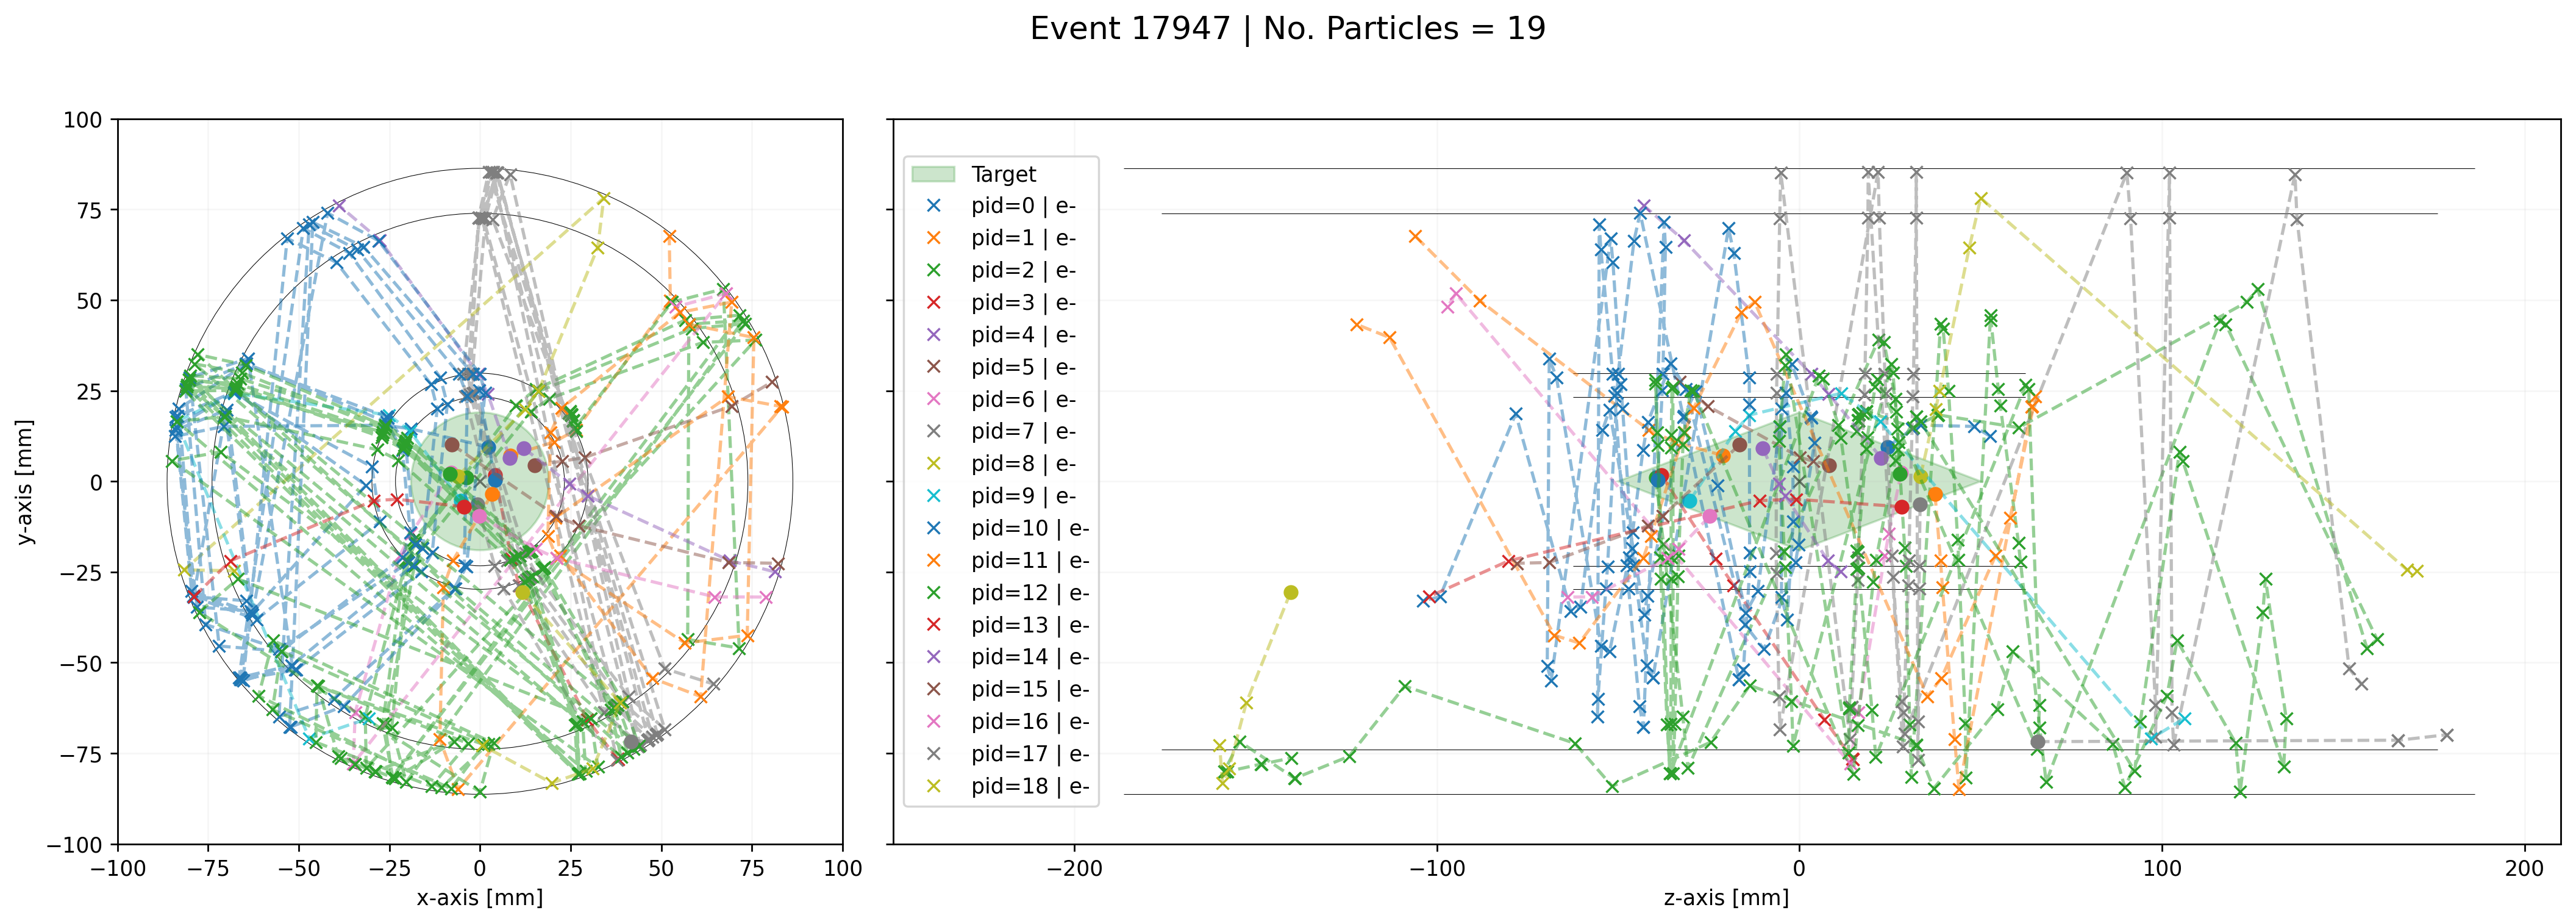

In [9]:
idx = 17947
hits, particles = load_event(idx, all_hits, all_tracks)
fig = plot_event(hits, particles)

In [10]:
event_hit_counts_batched = all_hits_batched['eventID'].value_counts()
event_track_counts_batched = all_tracks_batched['eventID'].value_counts()
event_hit_counts = all_hits['eventID'].value_counts()
event_track_counts = all_tracks['eventID'].value_counts()

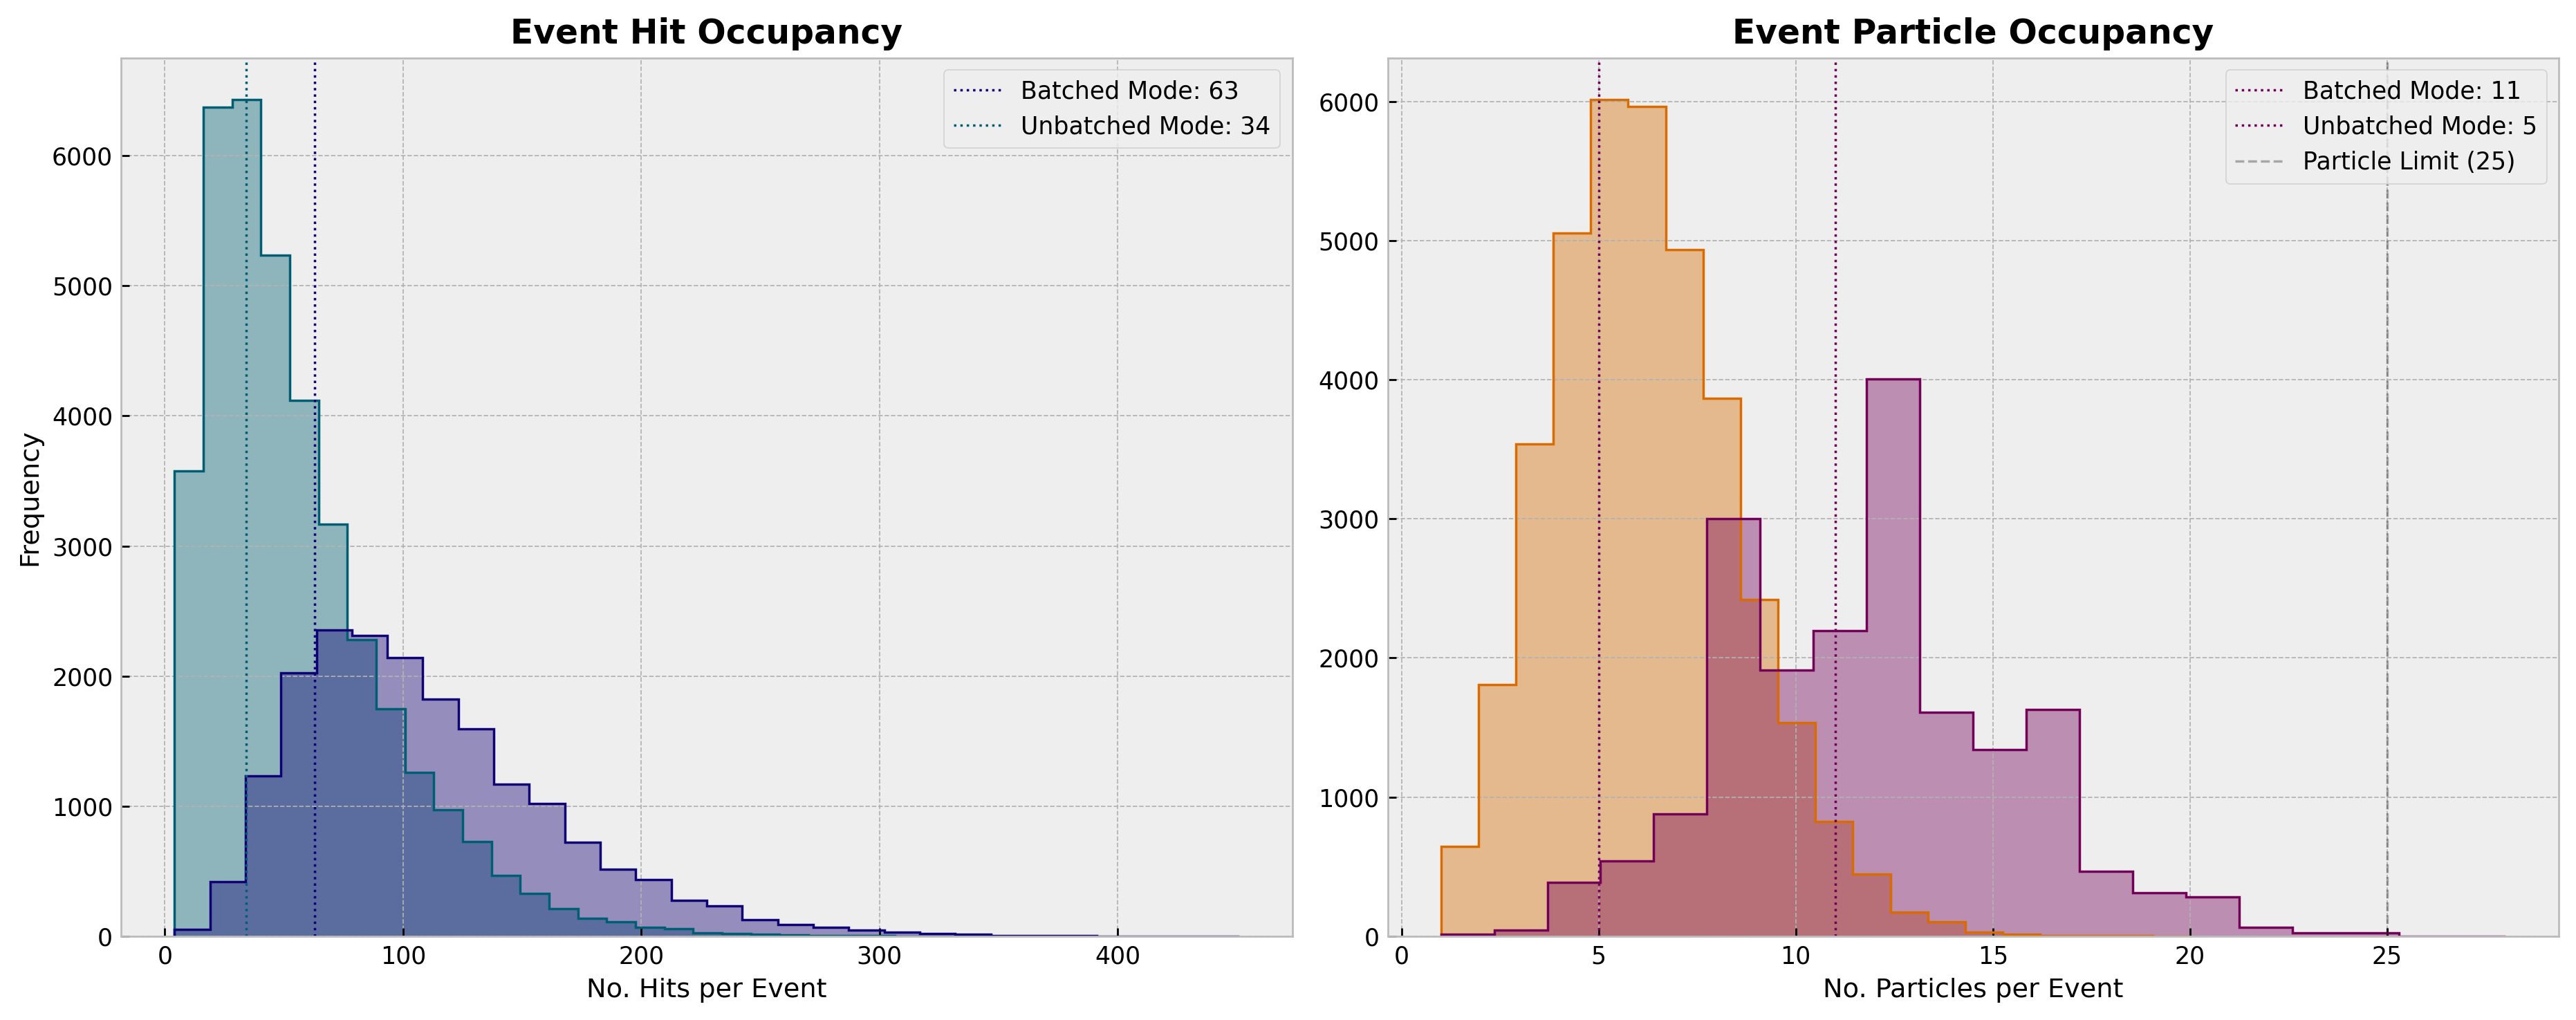

In [12]:
# Calculate modes
hit_mode = np.bincount(event_hit_counts).argmax()
particle_mode = np.bincount(event_track_counts).argmax()
batched_hit_mode = np.bincount(event_hit_counts_batched).argmax()
batched_particle_mode = np.bincount(event_track_counts_batched).argmax()

# Using a clean style
plt.style.use('bmh') 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), dpi=250)

# Plot 1: Hit Occupancy
ax1.hist(event_hit_counts,bins=30,histtype='step', linewidth=1,color='#005E73')
ax1.hist(event_hit_counts,bins=30,histtype='stepfilled',alpha=0.4,color='#005E73')

ax1.hist(event_hit_counts_batched,bins=30,histtype='step', linewidth=1,color='#100075')
ax1.hist(event_hit_counts_batched,bins=30,histtype='stepfilled',alpha=0.4,color='#100075')

ax1.axvline(batched_hit_mode, color='#100075', linestyle=':', linewidth=1, label=f'Batched Mode: {batched_hit_mode}')
ax1.axvline(hit_mode, color='#005E73', linestyle=':', linewidth=1, label=f'Unbatched Mode: {hit_mode}')

ax1.set_title('Event Hit Occupancy', fontsize=14, fontweight='bold')
ax1.set_xlabel('No. Hits per Event', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.legend()

# Plot 2: Particle Occupancy
ax2.hist(event_track_counts,bins=20,histtype='step',linewidth=1,color='#D96B00')
ax2.hist(event_track_counts,bins=20,histtype='stepfilled',alpha=0.4,color='#D96B00')

ax2.hist(event_track_counts_batched,bins=20,histtype='step',linewidth=1,color='#730058')
ax2.hist(event_track_counts_batched,bins=20,histtype='stepfilled',alpha=0.4,color='#730058')

ax2.axvline(batched_particle_mode, color='#730058', linestyle=':', linewidth=1, label=f'Batched Mode: {batched_particle_mode}')
ax2.axvline(particle_mode, color='#730058', linestyle=':', linewidth=1, label=f'Unbatched Mode: {particle_mode}')
ax2.axvline(25, color='black', linestyle='--', alpha=0.3, linewidth=1, label='Particle Limit (25)')
ax2.set_title('Event Particle Occupancy', fontsize=14, fontweight='bold')
ax2.set_xlabel('No. Particles per Event', fontsize=11)
ax2.legend()

plt.tight_layout()
plt.show()

### `relics`

In [52]:
particle_hits = hits[hits['particle_idx']==0]

In [51]:
x = particle_hits['x'].values
y = particle_hits['y'].values

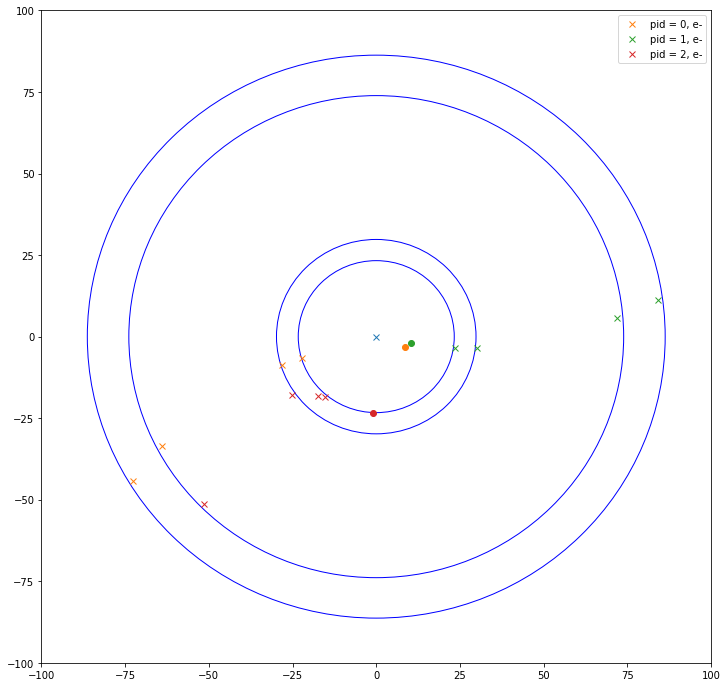

In [19]:
plt.figure(figsize=(12,12))
plt.xlim(-100,100)
plt.ylim(-100,100)
plt.plot(0,0, 'x')

ax = plt.gca()
circle1 = plt.Circle((0, 0), 23.3, color='b', fill=False)
circle2 = plt.Circle((0, 0), 29.8, color='b', fill=False)
circle3 = plt.Circle((0, 0), 73.9, color='b', fill=False)
circle4 = plt.Circle((0, 0), 86.3, color='b', fill=False)

ax.add_patch(circle1)
ax.add_patch(circle2)
ax.add_patch(circle3)
ax.add_patch(circle4)

for i, particle_idx in enumerate(hits['particle_idx'].unique()):
    particle_hits = hits[hits['particle_idx']==particle_idx]
    individual_particle = particles[particles['particle_idx']==particle_idx]
    
    vx = individual_particle['vx']
    vy = individual_particle['vy']
    
    x = particle_hits['x']
    y = particle_hits['y']
    pdg = int(particle_hits['pdg'].unique())
    
    line, = ax.plot(vx, vy, 'o')
    current_color = line.get_color()
    ax.plot(x, y, 'x', color=current_color, label = f'pid = {i}, {pid_label[pdg]}')
    
plt.legend()
plt.show()

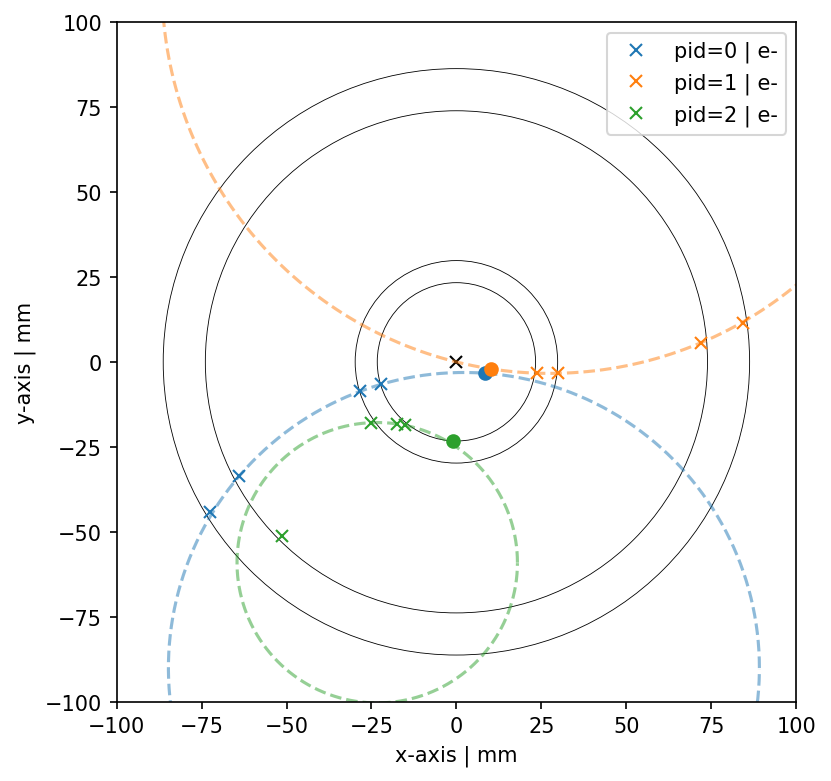

In [20]:
pid_label = {11: "e-", -11: "e-"}

plt.figure(figsize=(6,6), dpi=150)
plt.xlim(-100,100)
plt.ylim(-100,100)
plt.plot(0,0, 'x', color='black')
plt.xlabel('x-axis | mm')
plt.ylabel('y-axis | mm')

ax = plt.gca()
ax.set_aspect('equal', adjustable='box')
circle1 = plt.Circle((0, 0), 23.3, color='black', lw=0.4, fill=False)
circle2 = plt.Circle((0, 0), 29.8, color='black', lw=0.4, fill=False)
circle3 = plt.Circle((0, 0), 73.9, color='black', lw=0.4, fill=False)
circle4 = plt.Circle((0, 0), 86.3, color='black', lw=0.4, fill=False)

ax.add_patch(circle1)
ax.add_patch(circle2)
ax.add_patch(circle3)
ax.add_patch(circle4)

for i, particle_idx in enumerate(hits['particle_idx'].unique()):
    particle_hits = hits[hits['particle_idx']==particle_idx].copy()
    individual_particle = particles[particles['particle_idx']==particle_idx]
    pdg = int(individual_particle['pdg'])
    
    # extract hit and vertex coords
    vx = individual_particle['vx'].values[0]
    vy = individual_particle['vy'].values[0]
    vz = individual_particle['vz'].values[0]
    x_hits = particle_hits['x'].values
    y_hits = particle_hits['y'].values
    z_hits = particle_hits['z'].values
    
    # prepend vertex to hit array
    x_path = np.insert(x_hits, 0, vx)
    y_path = np.insert(y_hits, 0, vy)
    z_path = np.insert(z_hits, 0, vz)
    
    # plot track, vertex, hits 
    #line, = ax.plot(x_path, y_path, '--', alpha=0.5) 
    #color = line.get_color()
    #ax.plot(vx, vy, 'o', color=color) # The vertex
    
    circle_x, circle_y = fit_circle(x_hits, y_hits)
    line, = ax.plot(vx, vy, 'o')
    color = line.get_color()
    
    ax.plot(circle_x, circle_y, '--', alpha=0.5, color=color)
    ax.plot(x_hits, y_hits, 'x', color=color, label=f'pid={i} | {pid_label[pdg]}')
    
plt.legend()
plt.show()